### This notebook is used as a playground to run statistical tests across signals to incorporate in my multi frequency stat arb trading engine 

In [166]:
# Import

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import sys
sys.path.append(r"C:\Users\pcarg\OneDrive\Υπολογιστής\MFE UCLA\Last Quarter\Classes\Statistical Arbitrage\Final Project\Statistical Arbitrage Project")
from regime.regime_detection import compute_regime_signals
from regime.regime_mapping import get_book_actions
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [168]:
# Set style for plots

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

In [5]:
# Read

data = pd.read_csv("unified_cleaned_dataset.csv")

In [7]:
data.head()

,Date,CLc1,Cc1,HGc1,LCOc1,NGc1,Wc1,JETS,XLB,XLE,XLI,XLP,XLU,XLY,SPX
0,2015-05-01,-0.008050,-0.007586,0.015590,-0.004792,0.009088,0.006424,0.028196,0.016462,0.002298,0.012583,0.009097,0.005654,0.013810,0.010923
1,2015-05-04,-0.003719,-0.002780,-0.002558,-0.000150,0.016210,-0.001596,-0.008444,-0.002732,-0.002534,0.001598,0.001434,0.007421,0.002096,0.002941
2,2015-05-05,0.024945,0.006969,0.005472,0.016102,-0.014534,-0.011188,-0.026764,-0.011348,-0.012346,-0.013470,-0.007979,-0.022321,-0.010456,-0.011837
3,2015-05-06,0.008775,0.014533,-0.002551,0.003703,-0.001439,0.025323,-0.000833,0.000198,-0.003914,-0.000539,0.003093,-0.005479,-0.004095,-0.004456
4,2015-05-07,-0.032660,-0.023874,-0.002217,-0.032905,-0.015130,-0.021019,0.019183,0.004353,-0.010821,0.005213,0.002467,0.003673,0.005172,0.003774


In [9]:
data.tail()

,Date,CLc1,Cc1,HGc1,LCOc1,NGc1,Wc1,JETS,XLB,XLE,XLI,XLP,XLU,XLY,SPX
2656,2025-11-20,-0.005047,-0.007563,-0.009685,-0.002047,-0.016703,-0.018165,-0.015385,-0.014929,-0.011348,-0.016761,0.007189,-0.005086,-0.014921,-0.015567
2657,2025-11-21,-0.018262,-0.002345,0.009880,-0.012938,0.023692,0.000000,0.035051,0.022377,0.006302,0.012176,0.010901,0.001477,0.019624,0.009823
2658,2025-11-24,0.013434,-0.004113,-0.009284,0.012948,-0.006769,-0.009013,0.020400,0.001969,-0.002796,0.002473,-0.011553,0.011344,0.013348,0.015467
2659,2025-11-25,-0.015126,-0.000590,0.007557,-0.014045,-0.027479,0.009574,0.027989,0.014910,-0.006280,0.012800,0.013766,-0.003814,0.021400,0.009062
2660,2025-11-26,0.012079,0.019481,0.021002,0.010403,0.030289,0.003319,0.021392,0.012299,0.007561,0.005793,0.010889,0.013287,0.006855,0.006907


In [13]:
# Ensure datetime index

data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

In [15]:
# Asset class definitions

commodities = ['CLc1','Cc1','HGc1','LCOc1','NGc1','Wc1']
etfs       = ['JETS','XLB','XLE','XLI','XLP','XLU','XLY']
market_col = 'SPX'

In [17]:
# Split data

returns = data[commodities + etfs]
market = data[market_col]

Raw Lehman reversal

In [20]:
# Cross-sectional mean

cs_mean = returns.mean(axis=1)

In [22]:
# Raw reversal signal

rev_raw = -(returns.sub(cs_mean, axis=0))

In [24]:
# Z-score normalization

rev_raw_z = (rev_raw.sub(rev_raw.mean(axis=1), axis=0)
                      .div(rev_raw.std(axis=1), axis=0))

Beta neutral reversal

In [27]:
window = 60

residuals = pd.DataFrame(index=returns.index, columns=returns.columns)

for asset in returns.columns:
    df = pd.concat([returns[asset], market], axis=1).dropna()
    df.columns = ['r', 'mkt']
    
    cov = df['r'].rolling(window).cov(df['mkt'])
    var = df['mkt'].rolling(window).var()
    
    beta = cov / var
    res = df['r'] - beta * df['mkt']
    
    residuals.loc[res.index, asset] = res

In [29]:
# Reversal on residuals

K = 3
rev_beta = -residuals.rolling(K).sum()

In [31]:
# Normalize

rev_beta_z = (rev_beta.sub(rev_beta.mean(axis=1), axis=0)
                        .div(rev_beta.std(axis=1), axis=0))

Future returns

In [34]:
fwd_returns = returns.shift(-1)

IC Functions

In [97]:
def compute_ic(signal, future_returns):
    ic_list = []
    dates = []
    
    for t in signal.index[:-1]:
        x = signal.loc[t]
        y = future_returns.loc[t]
        
        mask = x.notna() & y.notna()
        
        if mask.sum() > 5:
            ic = spearmanr(x[mask], y[mask])[0]
            ic_list.append(ic)
            dates.append(t)
    
    return pd.Series(ic_list, index=dates)


def compute_ic_subset(signal, future_returns, asset_subset):
    ic_list = []
    dates = []
    
    for t in signal.index[:-1]:
        x = signal.loc[t, asset_subset]
        y = future_returns.loc[t, asset_subset]
        
        mask = x.notna() & y.notna()
        
        if mask.sum() > 3:
            ic = spearmanr(x[mask], y[mask])[0]
            ic_list.append(ic)
            dates.append(t)
    
    return pd.Series(ic_list, index=dates)


def compute_ic_decay(signal, returns, horizons=[1,2,3,5,10]):
    results = {}
    
    for h in horizons:
        fwd = returns.shift(-h)
        ic = compute_ic(signal, fwd)
        results[h] = ic.mean()
    
    return pd.Series(results)


def compute_ic_decay_subset(signal, returns, asset_subset, horizons=[1,2,3,5,10]):
    results = {}
    
    for h in horizons:
        fwd = returns.shift(-h)
        ic = compute_ic_subset(signal, fwd, asset_subset)
        results[h] = ic.mean()
    
    return pd.Series(results)


def summarize(name, ic):
    ic = ic.dropna()

    if len(ic) < 50:
        print(f"\n{name} (INSUFFICIENT DATA)")
        print("N:", len(ic))
        return

    X = np.ones(len(ic))

    model = sm.OLS(ic.values, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': 5}
    )

    print(f"\n{name}")
    print("-"*50)
    print("Mean IC:", ic.mean())
    print("Std IC:", ic.std())
    print("NW t-stat:", model.tvalues[0])
    print("N:", len(ic))

Run full IC

In [100]:
# FULL UNIVERSE
ic_raw_full  = compute_ic(rev_raw_z, fwd_returns)
ic_beta_full = compute_ic(rev_beta_z, fwd_returns)

# BY ASSET CLASS
ic_raw_comm  = compute_ic_subset(rev_raw_z, fwd_returns, commodities)
ic_raw_etf   = compute_ic_subset(rev_raw_z, fwd_returns, etfs)

ic_beta_comm = compute_ic_subset(rev_beta_z, fwd_returns, commodities)
ic_beta_etf  = compute_ic_subset(rev_beta_z, fwd_returns, etfs)

Print results

In [103]:
# FULL
summarize("RAW - FULL", ic_raw_full)
summarize("BETA - FULL", ic_beta_full)

# BY GROUP
summarize("RAW - COMMODITIES", ic_raw_comm)
summarize("RAW - ETFs", ic_raw_etf)

summarize("BETA - COMMODITIES", ic_beta_comm)
summarize("BETA - ETFs", ic_beta_etf)


RAW - FULL
--------------------------------------------------
Mean IC: 0.018831312346613633
Std IC: 0.38387601654093484
NW t-stat: 2.664808415451183
N: 2660

BETA - FULL
--------------------------------------------------
Mean IC: 0.017315324256843994
Std IC: 0.37903014977228944
NW t-stat: 2.439583097017343
N: 2599

RAW - COMMODITIES
--------------------------------------------------
Mean IC: 0.021942813735161198
Std IC: 0.5197483016038726
NW t-stat: 2.3153187422622996
N: 2660

RAW - ETFs
--------------------------------------------------
Mean IC: 0.011536456752332103
Std IC: 0.4759142015430141
NW t-stat: 1.2470137332307147
N: 2660

BETA - COMMODITIES
--------------------------------------------------
Mean IC: 0.02482634454603394
Std IC: 0.5243353454717871
NW t-stat: 2.5490160847157894
N: 2599

BETA - ETFs
--------------------------------------------------
Mean IC: 0.011261603393786223
Std IC: 0.4757917979135482
NW t-stat: 1.1816114596402576
N: 2599


IC Decay

In [106]:
print("\nIC DECAY - RAW FULL")
print(compute_ic_decay(rev_raw_z, returns))

print("\nIC DECAY - BETA FULL")
print(compute_ic_decay(rev_beta_z, returns))

print("\nIC DECAY - RAW ETFs")
print(compute_ic_decay_subset(rev_raw_z, returns, etfs))

print("\nIC DECAY - RAW COMMODITIES")
print(compute_ic_decay_subset(rev_raw_z, returns, commodities))

print("\nIC DECAY - BETA ETFs")
print(compute_ic_decay_subset(rev_beta_z, returns, etfs))

print("\nIC DECAY - BETA COMMODITIES")
print(compute_ic_decay_subset(rev_beta_z, returns, commodities))


IC DECAY - RAW FULL
1     0.018831
2     0.015428
3    -0.002309
5    -0.005735
10    0.002401
dtype: float64

IC DECAY - BETA FULL
1     0.017315
2     0.009381
3    -0.002718
5     0.000602
10   -0.003328
dtype: float64

IC DECAY - RAW ETFs
1     0.011536
2     0.002492
3     0.012329
5    -0.001459
10   -0.004003
dtype: float64

IC DECAY - RAW COMMODITIES
1     0.021943
2     0.022690
3    -0.004758
5    -0.000671
10   -0.003363
dtype: float64

IC DECAY - BETA ETFs
1     0.011262
2    -0.003119
3    -0.011574
5    -0.005420
10    0.001293
dtype: float64

IC DECAY - BETA COMMODITIES
1     0.024826
2     0.016573
3     0.001074
5     0.008117
10   -0.006268
dtype: float64


Portfolio Check

In [48]:
def compute_portfolio_returns(signal, returns):
    weights = signal.div(signal.abs().sum(axis=1), axis=0)
    pnl = (weights * returns.shift(-1)).sum(axis=1)
    return pnl

pnl_raw = compute_portfolio_returns(rev_raw_z, returns)
pnl_beta = compute_portfolio_returns(rev_beta_z, returns)

print("\nPortfolio RAW Sharpe:", pnl_raw.mean() / pnl_raw.std())
print("Portfolio BETA Sharpe:", pnl_beta.mean() / pnl_beta.std())


Portfolio RAW Sharpe: 0.002133993066261905
Portfolio BETA Sharpe: -0.0008812033304239343


In [51]:
# IC decay for commodity futures

print("\nIC DECAY - RAW COMMODITIES")
print(compute_ic_decay_subset(rev_raw_z, returns, commodities))

print("\nIC DECAY - BETA COMMODITIES")
print(compute_ic_decay_subset(rev_beta_z, returns, commodities))


IC DECAY - RAW COMMODITIES
1     0.021943
2     0.022690
3    -0.004758
5    -0.000671
10   -0.003363
dtype: float64

IC DECAY - BETA COMMODITIES
1     0.024826
2     0.016573
3     0.001074
5     0.008117
10   -0.006268
dtype: float64


In [107]:
# IC decay for ETFs

print("\nIC DECAY - RAW ETFs")
print(compute_ic_decay_subset(rev_raw_z, returns, etfs))

print("\nIC DECAY - BETA ETFs")
print(compute_ic_decay_subset(rev_beta_z, returns, etfs))


IC DECAY - RAW ETFs
1     0.011536
2     0.002492
3     0.012329
5    -0.001459
10   -0.004003
dtype: float64

IC DECAY - BETA ETFs
1     0.011262
2    -0.003119
3    -0.011574
5    -0.005420
10    0.001293
dtype: float64


Compute regimes using our regime detection - labeling package

In [65]:
# Package works with logreturns because it is DCC Garch based

log_returns = np.log(1 + returns)

C:\Users\pcarg\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Let's see what this refers to.

In [67]:
print(returns.min().sort_values())

CLc1    -3.059661
NGc1    -0.259537
LCOc1   -0.244036
HGc1    -0.222531
JETS    -0.201502
XLE     -0.201412
Cc1     -0.173865
XLY     -0.126686
XLU     -0.113577
XLI     -0.113441
XLB     -0.110084
Wc1     -0.106823
XLP     -0.093956
dtype: float64


In [69]:
bad_rows = returns[returns['CLc1'] < -1]
bad_rows

,CLc1,Cc1,HGc1,LCOc1,NGc1,Wc1,JETS,XLB,XLE,XLI,XLP,XLU,XLY
Date,,,,,,,,,,,,,
2020-04-20,-3.059661,-0.024825,-0.008073,-0.089387,0.097547,0.028585,-0.025087,-0.024672,-0.031222,-0.026624,-0.019669,-0.037832,-0.017444
2020-04-21,-1.266011,-0.015911,-0.028914,-0.244036,-0.053534,-0.003645,-0.018585,-0.024684,-0.017635,-0.023608,-0.021244,-0.016484,-0.025955


This is actually a real moment. It refers to crude prices turning negative during COVID. So we should not drop the rows for signal research as they have actual economic meaning. We should just remove it when we are trying to identify regime because garch will explode.

In [73]:
returns_regime = returns.copy()

# clip extreme tails (e.g. 5-sigma or hard cap)
returns_regime = returns_regime.clip(lower=-0.5, upper=0.5)

In [75]:
# Package works with logreturns because it is DCC Garch based

log_returns = np.log(1 + returns_regime)

In [77]:
# Call function to detect regimes

regime_df = compute_regime_signals(
    returns_df=log_returns,
    spread_raw_df=pd.DataFrame(index=returns.index)
)

    [DCC] Fitting GJR-GARCH on 2661 obs × 13 assets ...
    [DCC] Fitting DCC (model='DCC') ...
    [DCC] Converged: a=0.0153  b=0.9453  llh=-53327.3
    [DCC] Regime signals computed: shape=(2661, 10)  avg_rho=0.235  disp_mean=0.229  n_spikes=200 (7.5% of days)


In [79]:
# Isolate column as new series

regime_series = regime_df["regime"]

In [87]:
def compute_ic_by_regime(signal, future_returns, regime_series, asset_subset=None):
    results = {}

    for regime in regime_series.dropna().unique():
        dates = regime_series[regime_series == regime].index
        
        ic_list = []

        for t in dates:
            if t not in signal.index or t not in future_returns.index:
                continue
            
            if asset_subset is None:
                x = signal.loc[t]
                y = future_returns.loc[t]
            else:
                x = signal.loc[t, asset_subset]
                y = future_returns.loc[t, asset_subset]

            mask = x.notna() & y.notna()

            if mask.sum() > 3:
                ic = spearmanr(x[mask], y[mask])[0]
                if not np.isnan(ic):
                    ic_list.append(ic)

        # stricter sample requirement (important)
        if len(ic_list) > 50:
            ic_series = pd.Series(ic_list)

            # Constant-only regression
            X = np.ones(len(ic_series))

            model = sm.OLS(ic_series.values, X).fit(
                cov_type='HAC',
                cov_kwds={'maxlags': 5}
            )

            results[regime] = {
                "mean_ic": ic_series.mean(),
                "nw_tstat": model.tvalues[0],   # Newey–West t-stat
                "std_ic": ic_series.std(),
                "n": len(ic_series)
            }

    return pd.DataFrame(results).T.sort_values("mean_ic", ascending=False)

In [110]:
regime_series = regime_df["regime"]

print("BETA REVERSAL - FULL")
print(compute_ic_by_regime(rev_beta_z, fwd_returns, regime_series))

print("RAW REVERSAL - FULL")
print(compute_ic_by_regime(rev_raw_z, fwd_returns, regime_series))

print("BETA REVERSAL - COMMODITIES")
print(compute_ic_by_regime(rev_beta_z, fwd_returns, regime_series, commodities))

print("RAW REVERSAL - COMMODITIES")
print(compute_ic_by_regime(rev_raw_z, fwd_returns, regime_series, commodities))

print("BETA REVERSAL - ETFs")
print(compute_ic_by_regime(rev_beta_z, fwd_returns, regime_series, etfs))

print("RAW REVERSAL - ETFs")
print(compute_ic_by_regime(rev_raw_z, fwd_returns, regime_series, etfs))

BETA REVERSAL - FULL
            mean_ic  nw_tstat    std_ic       n
crowded    0.031495  1.109294  0.378531   213.0
clustered  0.030627  1.203075  0.400283   204.0
normal     0.019931  2.476815  0.375274  1982.0
crisis    -0.037282 -1.357011  0.392526   200.0
RAW REVERSAL - FULL
            mean_ic  nw_tstat    std_ic       n
crowded    0.035298  1.218823  0.386372   215.0
clustered  0.021007  0.857622  0.414258   204.0
normal     0.020807  2.601816  0.379272  2041.0
crisis    -0.021247 -0.904925  0.396037   200.0
BETA REVERSAL - COMMODITIES
            mean_ic  nw_tstat    std_ic       n
clustered  0.054062  1.704764  0.537821   204.0
crowded    0.029736  0.897416  0.514464   213.0
normal     0.028033  2.443437  0.521556  1982.0
crisis    -0.042000 -1.188413  0.546655   200.0
RAW REVERSAL - COMMODITIES
            mean_ic  nw_tstat    std_ic       n
clustered  0.107563  3.127020  0.526238   204.0
normal     0.024439  2.245404  0.516461  2041.0
crowded    0.001473  0.039565  0.514930 

Now let's investigate IC decay by regime

In [127]:
# Helper function 

def compute_ic_decay_by_regime(
    signal,
    returns,
    regime_series,
    asset_subset=None,
    horizons=[1,2,3,5,10]
):
    results = {}

    for regime in regime_series.dropna().unique():
        dates = regime_series[regime_series == regime].index

        horizon_results = {}

        for h in horizons:
            ic_list = []
            fwd = returns.shift(-h)

            for t in dates:
                if t not in signal.index or t not in fwd.index:
                    continue

                if asset_subset is None:
                    x = signal.loc[t]
                    y = fwd.loc[t]
                else:
                    x = signal.loc[t, asset_subset]
                    y = fwd.loc[t, asset_subset]

                mask = x.notna() & y.notna()

                if mask.sum() > 3:
                    ic = spearmanr(x[mask], y[mask])[0]
                    if not np.isnan(ic):
                        ic_list.append(ic)

            if len(ic_list) > 50:
                ic_series = pd.Series(ic_list)

                X = np.ones(len(ic_series))
                model = sm.OLS(ic_series.values, X).fit(
                    cov_type='HAC',
                    cov_kwds={'maxlags': max(5, h)}
                )

                horizon_results[h] = {
                    "mean_ic": ic_series.mean(),
                    "nw_tstat": model.tvalues[0],
                    "std_ic": ic_series.std(),
                    "n": len(ic_series)
                }

        if len(horizon_results) > 0:
            results[regime] = pd.DataFrame(horizon_results).T

    return results

In [129]:
res_raw_full = compute_ic_decay_by_regime(rev_raw_z, returns, regime_series)
res_beta_full = compute_ic_decay_by_regime(rev_beta_z, returns, regime_series)

res_raw_comm = compute_ic_decay_by_regime(
    rev_raw_z, returns, regime_series, commodities
)

res_beta_comm = compute_ic_decay_by_regime(
    rev_beta_z, returns, regime_series, commodities
)

res_raw_etf = compute_ic_decay_by_regime(
    rev_raw_z, returns, regime_series, etfs
)

res_beta_etf = compute_ic_decay_by_regime(
    rev_beta_z, returns, regime_series, etfs
)

In [130]:
def print_results(title, results):
    print(f"\n{'='*60}")
    print(title)
    print(f"{'='*60}")
    
    for regime, df in results.items():
        print(f"\n--- {regime.upper()} ---")
        print(df)

In [135]:
print_results("RAW FULL", res_raw_full)
print_results("BETA FULL", res_beta_full)

print_results("RAW COMMODITIES", res_raw_comm)
print_results("BETA COMMODITIES", res_beta_comm)

print_results("RAW ETFs", res_raw_etf)
print_results("BETA ETFs", res_beta_etf)


RAW FULL

--- NORMAL ---
     mean_ic  nw_tstat    std_ic       n
1   0.020807  2.601816  0.379272  2041.0
2   0.017352  2.056141  0.369529  2040.0
3  -0.004155 -0.519543  0.375846  2039.0
5  -0.001959 -0.245684  0.380559  2037.0
10 -0.000918 -0.112916  0.380137  2032.0

--- CROWDED ---
     mean_ic  nw_tstat    std_ic      n
1   0.035298  1.218823  0.386372  215.0
2  -0.030951 -1.265951  0.382361  215.0
3   0.008177  0.329238  0.370774  215.0
5  -0.022438 -0.698314  0.402938  215.0
10  0.016988  0.666509  0.376953  215.0

--- CRISIS ---
     mean_ic  nw_tstat    std_ic      n
1  -0.021247 -0.904925  0.396037  200.0
2   0.004687  0.180476  0.393309  200.0
3   0.042433  1.605738  0.375612  200.0
5  -0.043563 -1.699648  0.402412  200.0
10  0.023118  0.989821  0.402180  200.0

--- CLUSTERED ---
     mean_ic  nw_tstat    std_ic      n
1   0.021007  0.857622  0.414258  204.0
2   0.055596  2.274465  0.365475  204.0
3  -0.038779 -1.474963  0.376968  204.0
5   0.011245  0.375921  0.406826  20

In [137]:
def pivot_mean_ic(results):
    out = {}
    for regime, df in results.items():
        out[regime] = df["mean_ic"]
    return pd.DataFrame(out)

In [139]:
print("\nRAW — FULL UNIVERSE (MEAN IC)")
print(pivot_mean_ic(res_raw_full))

print("\nBETA — FULL UNIVERSE (MEAN IC)")
print(pivot_mean_ic(res_beta_full))

print("\nRAW — COMMODITIES (MEAN IC)")
print(pivot_mean_ic(res_raw_comm))

print("\nBETA — COMMODITIES (MEAN IC)")
print(pivot_mean_ic(res_beta_comm))

print("\nRAW — ETFs (MEAN IC)")
print(pivot_mean_ic(res_raw_etf))

print("\nBETA — ETFs (MEAN IC)")
print(pivot_mean_ic(res_beta_etf))


RAW — FULL UNIVERSE (MEAN IC)
      normal   crowded    crisis  clustered
1   0.020807  0.035298 -0.021247   0.021007
2   0.017352 -0.030951  0.004687   0.055596
3  -0.004155  0.008177  0.042433  -0.038779
5  -0.001959 -0.022438 -0.043563   0.011245
10 -0.000918  0.016988  0.023118  -0.000225

BETA — FULL UNIVERSE (MEAN IC)
      normal   crowded    crisis  clustered
1   0.019931  0.031495 -0.037282   0.030627
2   0.008300 -0.006423  0.048846  -0.002316
3  -0.003461 -0.024790  0.058544  -0.032521
5   0.008949 -0.025771 -0.052098  -0.001131
10 -0.006133 -0.005056  0.008461   0.014045

RAW — COMMODITIES (MEAN IC)
      normal   crowded    crisis  clustered
1   0.024439  0.001473 -0.068857   0.107563
2   0.024053 -0.037444  0.020000   0.075070
3  -0.006923  0.025173  0.064000  -0.082073
5   0.007611 -0.059664 -0.021429  -0.000840
10 -0.006983 -0.004037  0.024857   0.005734

BETA — COMMODITIES (MEAN IC)
      normal   crowded    crisis  clustered
1   0.028033  0.029736 -0.042000   0.05406

Time split test. Question: Did something change post 2020? Is the relationship real or is it an artefact of our sample?

In [142]:
split_date = "2020-01-01"

In [155]:
def compute_ic_decay_by_regime_subset(
    signal,
    returns,
    regime_series,
    start_date=None,
    end_date=None,
    asset_subset=None,
    horizons=[1,2,3,5,10]
):
    mask = pd.Series(True, index=signal.index)

    if start_date is not None:
        mask &= signal.index >= pd.to_datetime(start_date)
    if end_date is not None:
        mask &= signal.index < pd.to_datetime(end_date)

    return compute_ic_decay_by_regime(
        signal.loc[mask],
        returns.loc[mask],
        regime_series.loc[mask],
        asset_subset=asset_subset,
        horizons=horizons
    )

In [157]:
res_raw_full_pre = compute_ic_decay_by_regime_subset(
    rev_raw_z, returns, regime_series, end_date=split_date
)

res_raw_full_post = compute_ic_decay_by_regime_subset(
    rev_raw_z, returns, regime_series, start_date=split_date
)

res_beta_full_pre = compute_ic_decay_by_regime_subset(
    rev_beta_z, returns, regime_series, end_date=split_date
)

res_beta_full_post = compute_ic_decay_by_regime_subset(
    rev_beta_z, returns, regime_series, start_date=split_date
)

res_raw_comm_pre = compute_ic_decay_by_regime_subset(
    rev_raw_z, returns, regime_series, end_date=split_date, asset_subset=commodities
)

res_raw_comm_post = compute_ic_decay_by_regime_subset(
    rev_raw_z, returns, regime_series, start_date=split_date, asset_subset=commodities
)

res_beta_comm_pre = compute_ic_decay_by_regime_subset(
    rev_beta_z, returns, regime_series, end_date=split_date, asset_subset=commodities
)

res_beta_comm_post = compute_ic_decay_by_regime_subset(
    rev_beta_z, returns, regime_series, start_date=split_date, asset_subset=commodities
)

res_raw_etf_pre = compute_ic_decay_by_regime_subset(
    rev_raw_z, returns, regime_series, end_date=split_date, asset_subset=etfs
)

res_raw_etf_post = compute_ic_decay_by_regime_subset(
    rev_raw_z, returns, regime_series, start_date=split_date, asset_subset=etfs
)

res_beta_etf_pre = compute_ic_decay_by_regime_subset(
    rev_beta_z, returns, regime_series, end_date=split_date, asset_subset=etfs
)

res_beta_etf_post = compute_ic_decay_by_regime_subset(
    rev_beta_z, returns, regime_series, start_date=split_date, asset_subset=etfs
)

In [159]:
print("\nRAW FULL PRE")
print(pivot_mean_ic(res_raw_full_pre))

print("\nRAW FULL POST")
print(pivot_mean_ic(res_raw_full_post))

print("\nBETA FULL PRE")
print(pivot_mean_ic(res_beta_full_pre))

print("\nBETA FULL POST")
print(pivot_mean_ic(res_beta_full_post))


print("\nRAW COMM PRE")
print(pivot_mean_ic(res_raw_comm_pre))

print("\nRAW COMM POST")
print(pivot_mean_ic(res_raw_comm_post))

print("\nBETA COMM PRE")
print(pivot_mean_ic(res_beta_comm_pre))

print("\nBETA COMM POST")
print(pivot_mean_ic(res_beta_comm_post))


print("\nRAW ETF PRE")
print(pivot_mean_ic(res_raw_etf_pre))

print("\nRAW ETF POST")
print(pivot_mean_ic(res_raw_etf_post))

print("\nBETA ETF PRE")
print(pivot_mean_ic(res_beta_etf_pre))

print("\nBETA ETF POST")
print(pivot_mean_ic(res_beta_etf_post))


RAW FULL PRE
      normal   crowded    crisis  clustered
1   0.008892  0.016066  0.016126   0.070170
2   0.011893 -0.027333  0.050815   0.077559
3  -0.012397 -0.029629 -0.026309  -0.026415
5   0.000633 -0.093059 -0.006401   0.049110
10 -0.002525 -0.021905 -0.015723   0.009761

RAW FULL POST
      normal  clustered   crowded    crisis
1   0.030090  -0.031136  0.046469 -0.047760
2   0.020925   0.032301 -0.033052 -0.028036
3   0.002544  -0.051893  0.030138  0.091199
5  -0.003655  -0.028916  0.018584 -0.069926
10  0.000800  -0.010816  0.044834  0.050672

BETA FULL PRE
      normal   crowded    crisis  clustered
1   0.012316  0.038033 -0.022579   0.048044
2   0.006943 -0.037248  0.027671  -0.006906
3  -0.007206 -0.018410  0.048789  -0.041885
5   0.012891 -0.061153 -0.021538   0.026060
10  0.008595  0.022881 -0.006951   0.007064

BETA FULL POST
      normal  clustered   crowded    crisis
1   0.025514   0.012155  0.027792 -0.047713
2   0.008759   0.002553  0.011029  0.063868
3  -0.000352  -0

Now evaluate rolling IC.

In [162]:
def compute_rolling_ic(signal, returns, window=252, asset_subset=None):
    fwd = returns.shift(-1)

    ic_list = []

    for t in signal.index[:-1]:
        if asset_subset is None:
            x = signal.loc[t]
            y = fwd.loc[t]
        else:
            x = signal.loc[t, asset_subset]
            y = fwd.loc[t, asset_subset]

        mask = x.notna() & y.notna()

        if mask.sum() > 3:
            ic = spearmanr(x[mask], y[mask])[0]
        else:
            ic = np.nan

        ic_list.append(ic)

    ic_series = pd.Series(ic_list, index=signal.index[:-1])
    return ic_series.rolling(window).mean()

In [164]:
# FULL
roll_raw_full  = compute_rolling_ic(rev_raw_z, returns)
roll_beta_full = compute_rolling_ic(rev_beta_z, returns)

# COMMODITIES
roll_raw_comm  = compute_rolling_ic(rev_raw_z, returns, asset_subset=commodities)
roll_beta_comm = compute_rolling_ic(rev_beta_z, returns, asset_subset=commodities)

# ETFs
roll_raw_etf   = compute_rolling_ic(rev_raw_z, returns, asset_subset=etfs)
roll_beta_etf  = compute_rolling_ic(rev_beta_z, returns, asset_subset=etfs)

Visualize a bit

In [171]:
# Helper to plot heatmap for IC

def plot_ic_heatmap(results, title):
    df = pivot_mean_ic(results).sort_index()

    fig, ax = plt.subplots()

    im = ax.imshow(df.values, aspect='auto')

    ax.set_xticks(np.arange(len(df.columns)))
    ax.set_yticks(np.arange(len(df.index)))

    ax.set_xticklabels(df.columns)
    ax.set_yticklabels(df.index)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = df.iloc[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center")

    ax.set_title(title)

    fig.colorbar(im)
    plt.show()

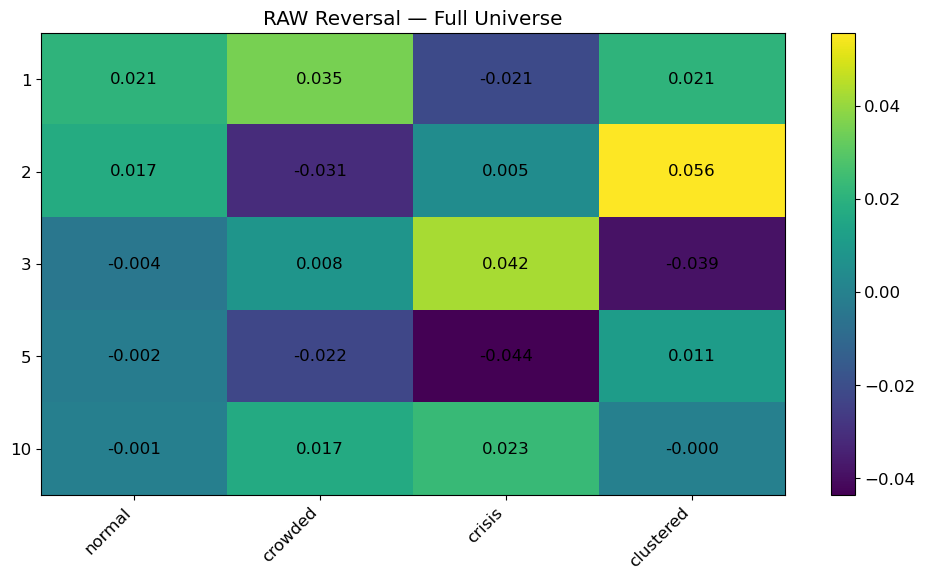

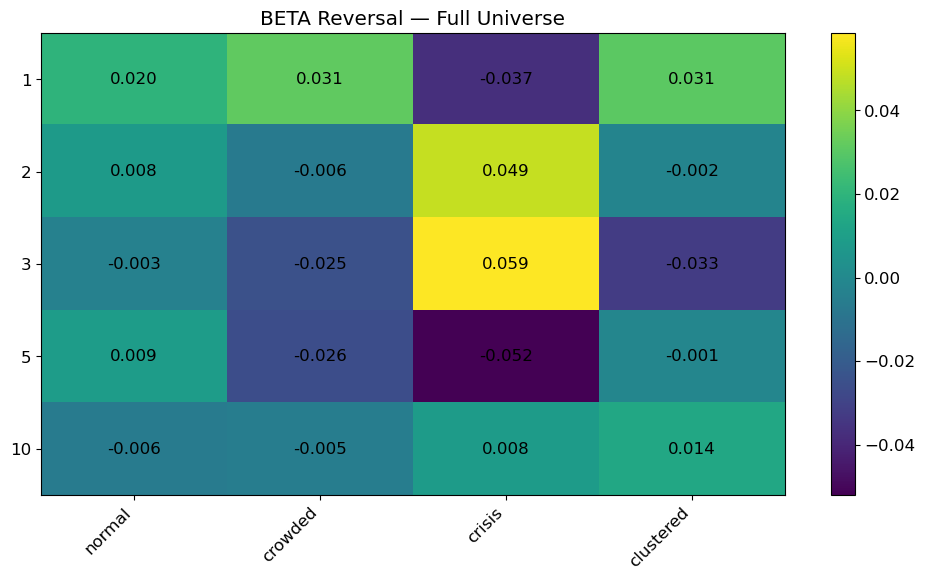

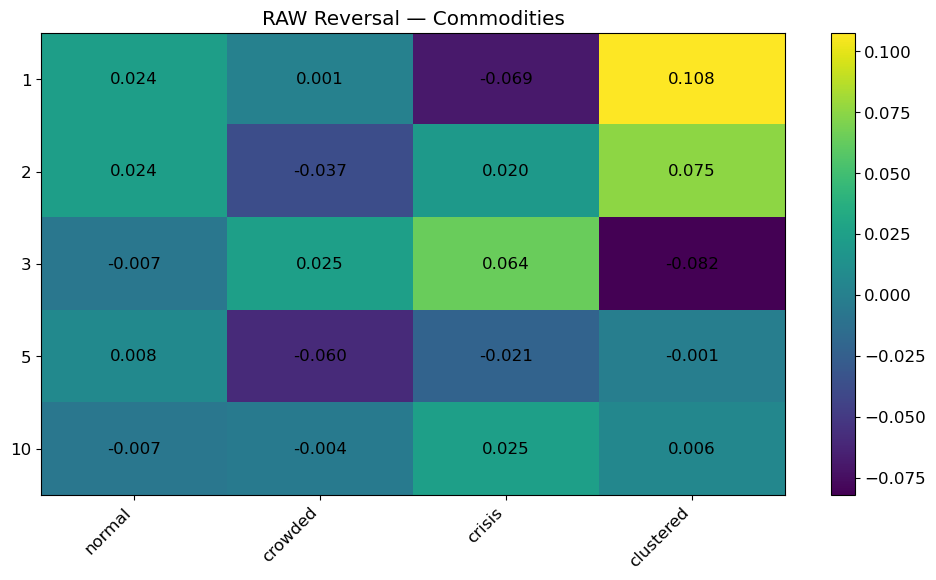

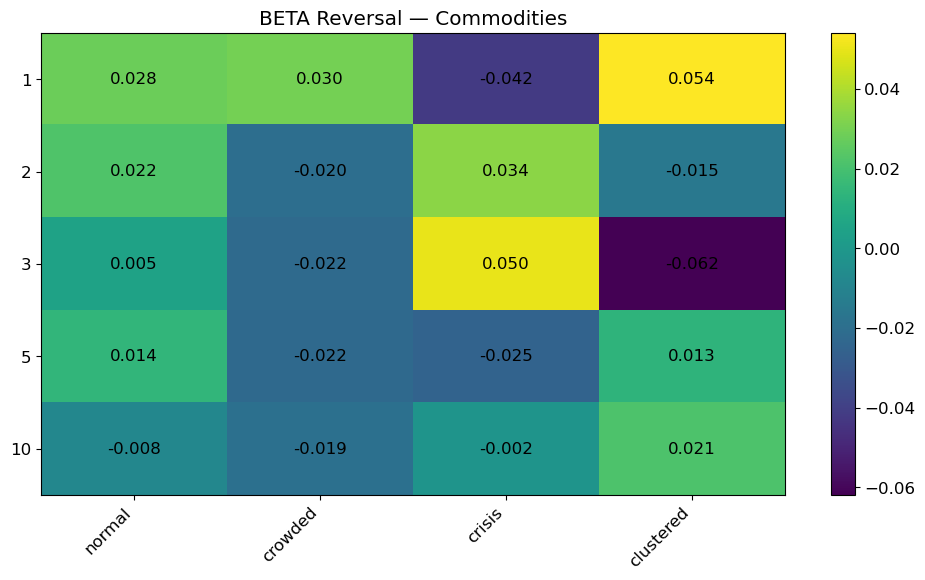

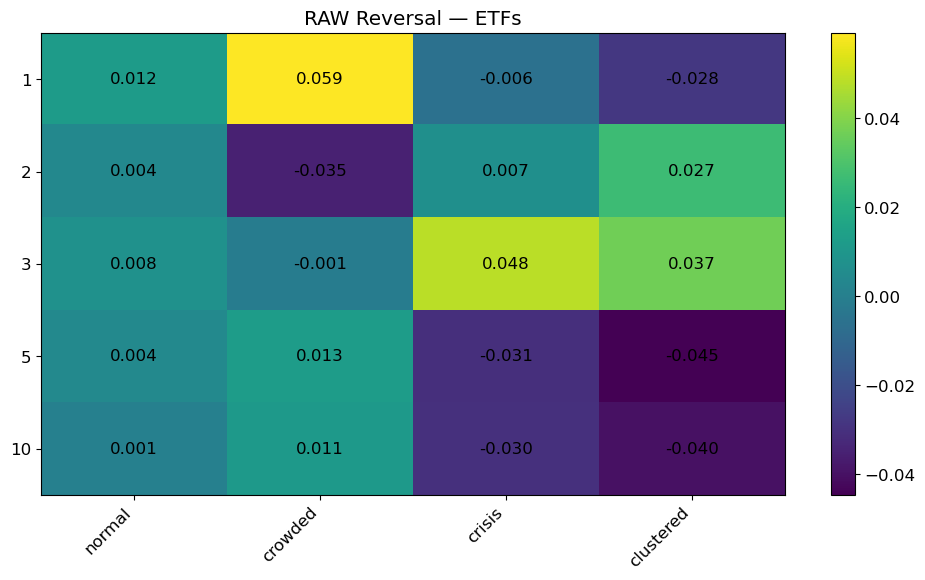

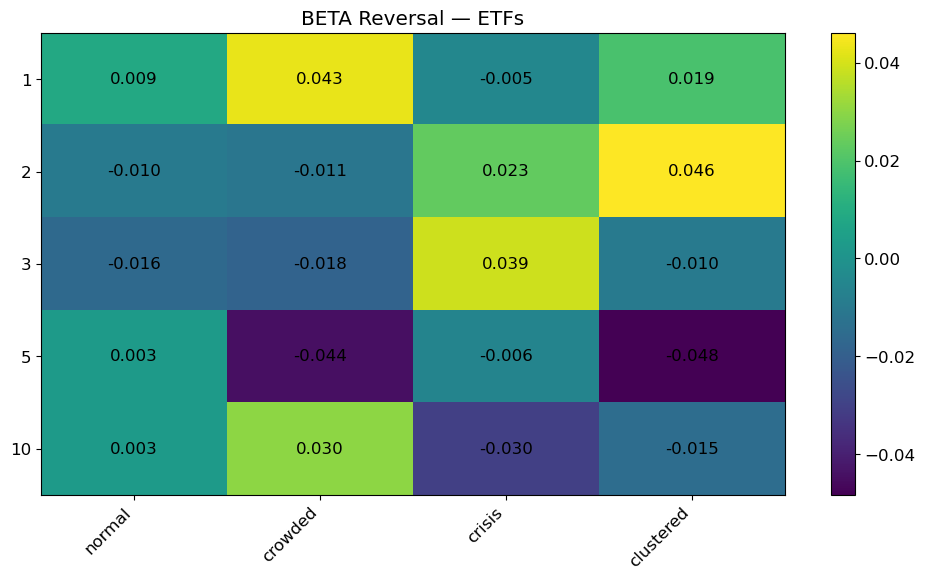

In [173]:
# Call and plot

plot_ic_heatmap(res_raw_full,  "RAW Reversal — Full Universe")
plot_ic_heatmap(res_beta_full, "BETA Reversal — Full Universe")

plot_ic_heatmap(res_raw_comm,  "RAW Reversal — Commodities")
plot_ic_heatmap(res_beta_comm, "BETA Reversal — Commodities")

plot_ic_heatmap(res_raw_etf,   "RAW Reversal — ETFs")
plot_ic_heatmap(res_beta_etf,  "BETA Reversal — ETFs")

In [175]:
# Helper to plot IC curves

def plot_ic_curves(results, title):
    df = pivot_mean_ic(results).sort_index()

    plt.figure()

    for col in df.columns:
        plt.plot(df.index, df[col], marker='o', label=col)

    plt.axhline(0, linestyle='--')
    plt.xlabel("Horizon")
    plt.ylabel("Mean IC")
    plt.title(title)
    plt.legend()
    plt.show()

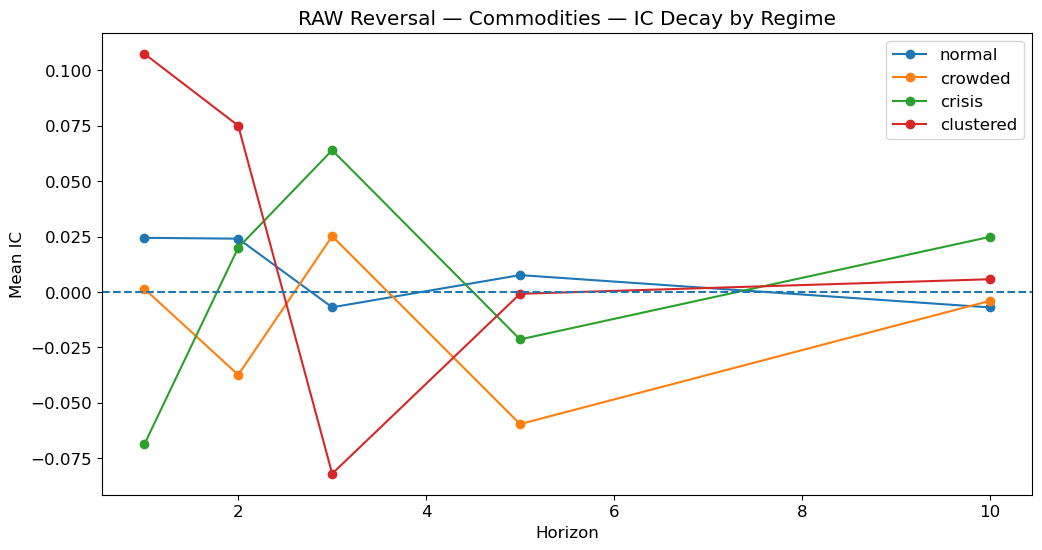

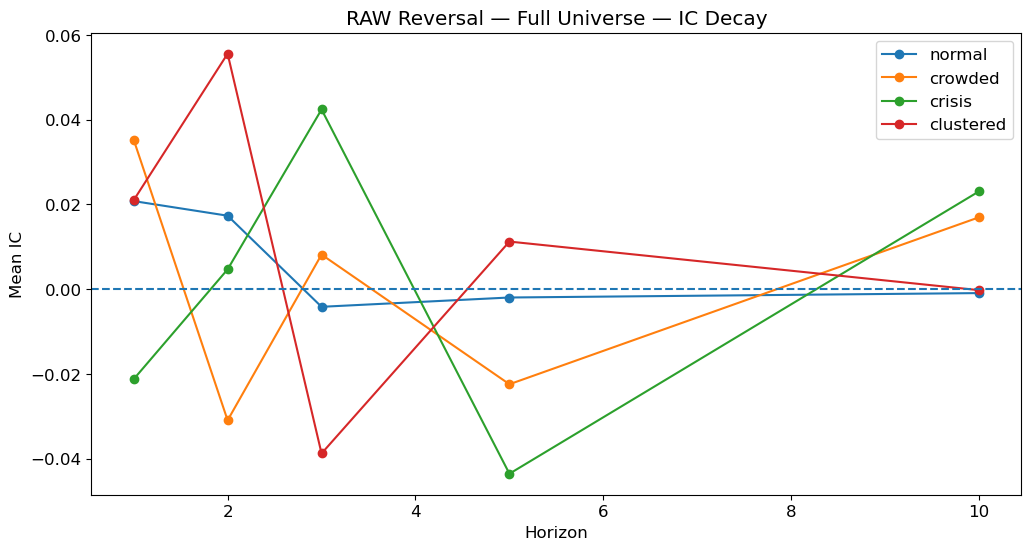

In [177]:
# Call

plot_ic_curves(res_raw_comm, "RAW Reversal — Commodities — IC Decay by Regime")
plot_ic_curves(res_raw_full, "RAW Reversal — Full Universe — IC Decay")

In [179]:
# Helper to plot helper IC

def plot_rolling_ic(series, title):
    plt.figure()
    series.plot()
    plt.axhline(0, linestyle='--')
    plt.title(title)
    plt.ylabel("Rolling IC")
    plt.show()

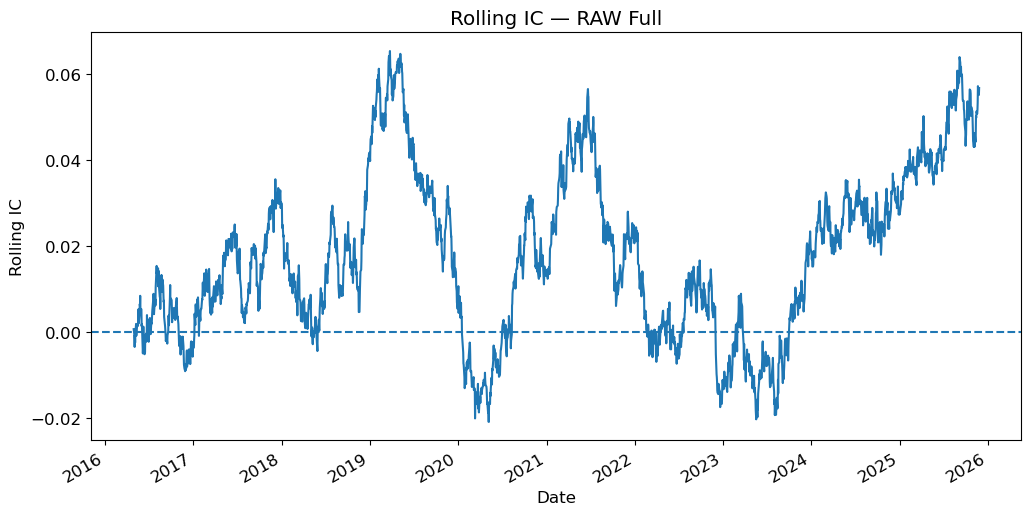

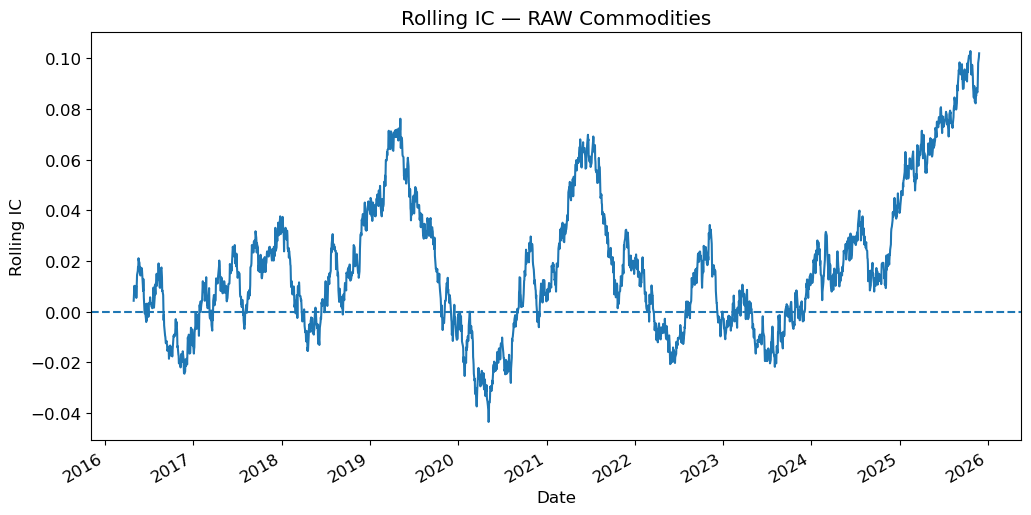

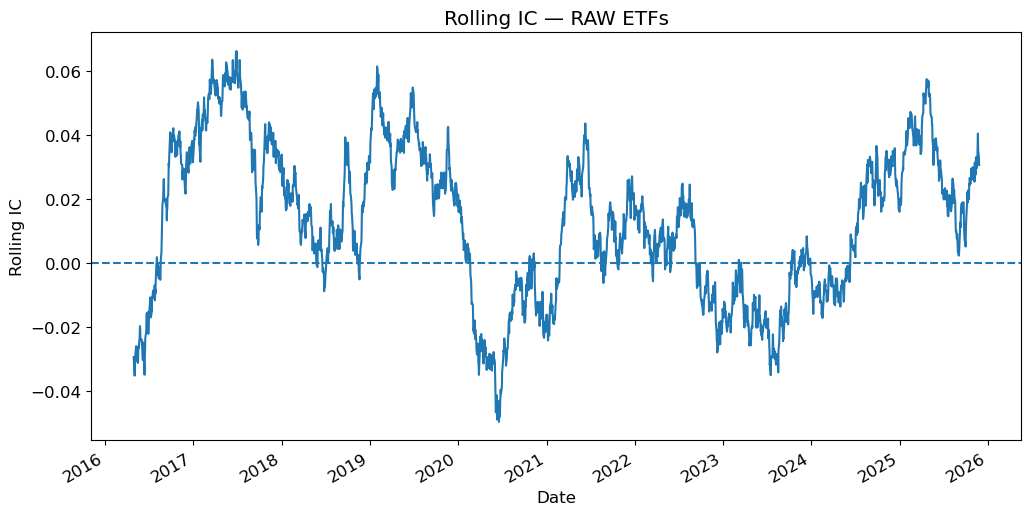

In [181]:
# Call

plot_rolling_ic(roll_raw_full, "Rolling IC — RAW Full")
plot_rolling_ic(roll_raw_comm, "Rolling IC — RAW Commodities")
plot_rolling_ic(roll_raw_etf,  "Rolling IC — RAW ETFs")

In [183]:
# Helper to plot regime frequency - Basically sanity check

def plot_regime_frequency(regime_series):
    freq = regime_series.value_counts(normalize=True)

    freq.plot(kind="bar")
    plt.title("Regime Frequency")
    plt.ylabel("Fraction of Time")
    plt.show()

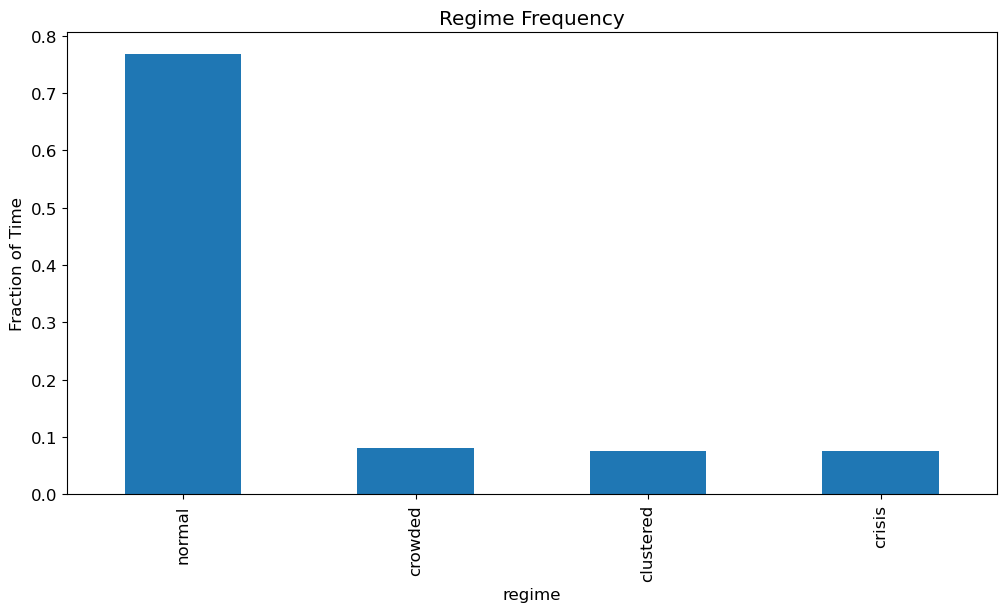

In [185]:
# Call

plot_regime_frequency(regime_series)

In [187]:
# Helper to plot regimes over time

def plot_regime_timeline(regime_series):
    mapping = {r:i for i, r in enumerate(regime_series.unique())}
    numeric = regime_series.map(mapping)

    plt.figure(figsize=(14,3))
    plt.scatter(regime_series.index, numeric, s=2)

    plt.yticks(list(mapping.values()), list(mapping.keys()))
    plt.title("Regime Timeline")
    plt.show()

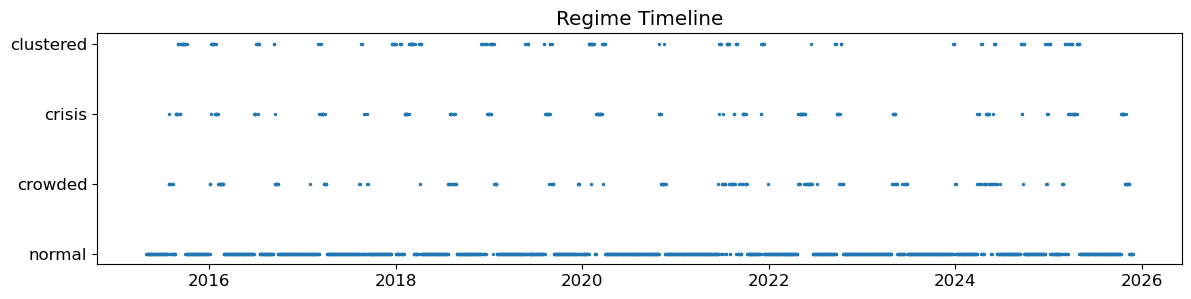

In [189]:
# Call

plot_regime_timeline(regime_series)

In [191]:
# Helper to plot signal vs return

def plot_signal_vs_return(signal, returns, asset_subset=None):
    fwd = returns.shift(-1)

    x_all = []
    y_all = []

    for t in signal.index[:-1]:
        if asset_subset is None:
            x = signal.loc[t]
            y = fwd.loc[t]
        else:
            x = signal.loc[t, asset_subset]
            y = fwd.loc[t, asset_subset]

        mask = x.notna() & y.notna()

        x_all.extend(x[mask])
        y_all.extend(y[mask])

    plt.scatter(x_all, y_all, alpha=0.2)
    plt.axhline(0)
    plt.axvline(0)
    plt.title("Signal vs Future Return")
    plt.xlabel("Signal")
    plt.ylabel("Next Return")
    plt.show()

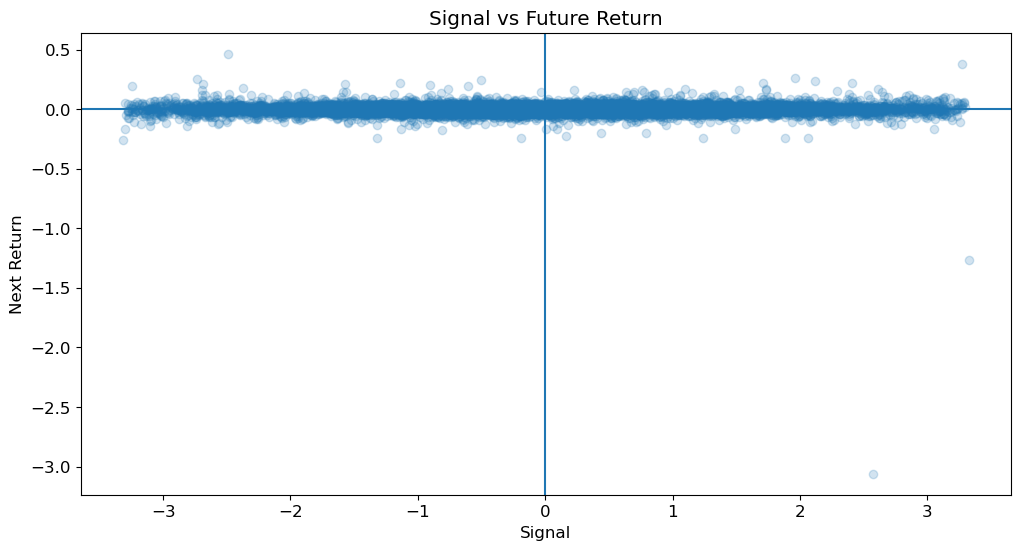

In [193]:
# Call

plot_signal_vs_return(rev_raw_z, returns)